# Waste Classification Using DenseNet121
### VS Code / Local Jupyter Version

## Step 1: Install Dependencies

In [ ]:
# Run this once — comment out after first run
#import subprocess, sys
#subprocess.check_call([sys.executable, "-m", "pip", "install",
#    "tensorflow", "numpy", "pandas", "matplotlib",
#    "scikit-learn", "seaborn", "Pillow", "-q"])
#print("All packages installed!")


All packages installed!


## Step 2: Import Libraries

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras import layers, models
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input
from PIL import Image

print("TensorFlow version:", tf.__version__)
print("All libraries imported successfully!")


TensorFlow version: 2.21.0
All libraries imported successfully!


## Step 3: Dataset Configuration


In [3]:
# ── CHANGE THIS TO YOUR LOCAL DATASET PATH ───────────────────────────────────
DATA_DIR = r"C:\Users\Student\Desktop\mini_project\Final_Dataset"

IMG_HEIGHT  = 224
IMG_WIDTH   = 224
BATCH_SIZE  = 32
SEED        = 123

# Saved model paths (local)
MODEL_SAVE_PATH    = r"C:\Users\Student\Desktop\mini_project\initial_model.keras"
FINETUNED_PATH     = r"C:\Users\Student\Desktop\mini_project\finetuned_model.keras"
FINAL_MODEL_PATH   = r"C:\Users\Student\Desktop\mini_project\final_model.keras"
CLASS_NAMES_PATH   = r"C:\Users\Student\Desktop\mini_project\class_names.pkl"

print("Dataset path :", DATA_DIR)
print("Path exists  :", os.path.exists(DATA_DIR))


Dataset path : C:\Users\Student\Desktop\mini_project\Final_Dataset
Path exists  : True


## Step 4: Explore Dataset Structure

In [4]:
main_categories  = []
subcategory_info = []

for main_category in sorted(os.listdir(DATA_DIR)):
    main_path = os.path.join(DATA_DIR, main_category)
    if not os.path.isdir(main_path):
        continue
    main_categories.append(main_category)

    for subcategory in sorted(os.listdir(main_path)):
        sub_path = os.path.join(main_path, subcategory)
        if not os.path.isdir(sub_path):
            continue

        image_count = sum(
            1 for f in os.listdir(sub_path)
            if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp"))
        )
        subcategory_info.append({
            "Main Category": main_category,
            "Subcategory"  : subcategory,
            "Image Count"  : image_count
        })

print("Main Categories:")
for c in main_categories:
    print("  -", c)

df_info = pd.DataFrame(subcategory_info)
print("\nDataset Summary:")
print(df_info.to_string(index=False))


Main Categories:
  - Biodegradable
  - Hazardous
  - Non-biodegradable

Dataset Summary:
    Main Category           Subcategory  Image Count
    Biodegradable             Cardboard          461
    Biodegradable               Organic            0
    Biodegradable                 Paper          500
    Biodegradable         Textile Trash          318
        Hazardous               Battery          756
        Hazardous                Paints          149
        Hazardous            Pesticides          136
Non-biodegradable                  Cans          262
Non-biodegradable       Ceramic_product          129
Non-biodegradable               Diapers          140
Non-biodegradable                 Glass          420
Non-biodegradable                 Metal          790
Non-biodegradable               Plastic          921
Non-biodegradable       Plastic_bottles          124
Non-biodegradable Platics_bags_wrappers          134
Non-biodegradable       Sanitary_napkin          110
Non-biodeg

## Step 5: Prepare Image Paths and Labels

In [5]:
image_records = []

for main_category in sorted(os.listdir(DATA_DIR)):
    main_path = os.path.join(DATA_DIR, main_category)
    if not os.path.isdir(main_path):
        continue

    for subcategory in sorted(os.listdir(main_path)):
        sub_path = os.path.join(main_path, subcategory)
        if not os.path.isdir(sub_path):
            continue

        for filename in os.listdir(sub_path):
            if filename.lower().endswith((".jpg", ".jpeg", ".png", ".bmp")):
                image_records.append({
                    "image_path"    : os.path.join(sub_path, filename),
                    "subcategory"   : subcategory,
                    "main_category" : main_category
                })

df = pd.DataFrame(image_records)
print("Total images       :", len(df))
print("Total subcategories:", df["subcategory"].nunique())
print(df.head())


Total images       : 5681
Total subcategories: 17
                                          image_path subcategory  \
0  C:\Users\Student\Desktop\mini_project\Final_Da...   Cardboard   
1  C:\Users\Student\Desktop\mini_project\Final_Da...   Cardboard   
2  C:\Users\Student\Desktop\mini_project\Final_Da...   Cardboard   
3  C:\Users\Student\Desktop\mini_project\Final_Da...   Cardboard   
4  C:\Users\Student\Desktop\mini_project\Final_Da...   Cardboard   

   main_category  
0  Biodegradable  
1  Biodegradable  
2  Biodegradable  
3  Biodegradable  
4  Biodegradable  


## Step 6: Class Names & Distribution

Number of waste classes: 17

Classes:
   0: Battery
   1: Cans
   2: Cardboard
   3: Ceramic_product
   4: Diapers
   5: Glass
   6: Metal
   7: Paints
   8: Paper
   9: Pesticides
  10: Plastic
  11: Plastic_bottles
  12: Platics_bags_wrappers
  13: Sanitary_napkin
  14: Shoes
  15: Styrofoam_product
  16: Textile Trash

Class Image Counts:
subcategory
Battery                  756
Cans                     262
Cardboard                461
Ceramic_product          129
Diapers                  140
Glass                    420
Metal                    790
Paints                   149
Paper                    500
Pesticides               136
Plastic                  921
Plastic_bottles          124
Platics_bags_wrappers    134
Sanitary_napkin          110
Shoes                    213
Styrofoam_product        118
Textile Trash            318


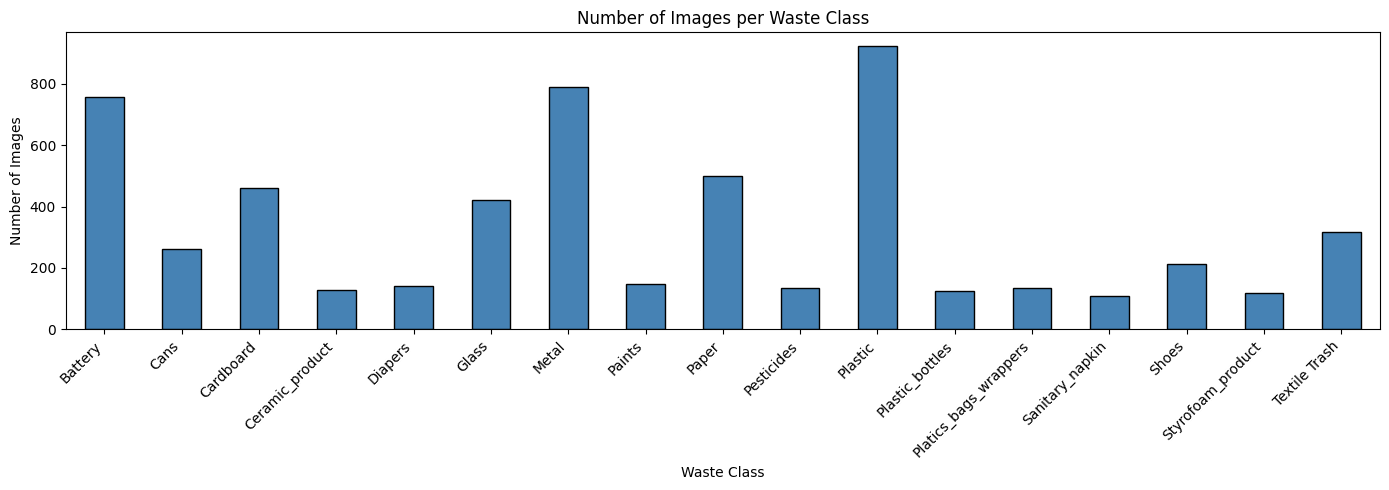

In [6]:
class_names = sorted(df["subcategory"].unique())
NUM_CLASSES = len(class_names)

print(f"Number of waste classes: {NUM_CLASSES}")
print("\nClasses:")
for i, c in enumerate(class_names):
    print(f"  {i:>2}: {c}")

# Plot class distribution
class_counts = df["subcategory"].value_counts().sort_index()
print("\nClass Image Counts:")
print(class_counts.to_string())

plt.figure(figsize=(14, 5))
class_counts.plot(kind="bar", color="steelblue", edgecolor="black")
plt.title("Number of Images per Waste Class")
plt.xlabel("Waste Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## Step 7: Split Dataset (70 / 15 / 15)

In [7]:
train_df, temp_df = train_test_split(
    df, test_size=0.30, random_state=SEED, stratify=df["subcategory"]
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=SEED, stratify=temp_df["subcategory"]
)

print(f"Training images   : {len(train_df)}")
print(f"Validation images : {len(val_df)}")
print(f"Testing images    : {len(test_df)}")
print(f"Total images      : {len(df)}")


Training images   : 3976
Validation images : 852
Testing images    : 853
Total images      : 5681


## Step 8: Visualize Sample Training Images

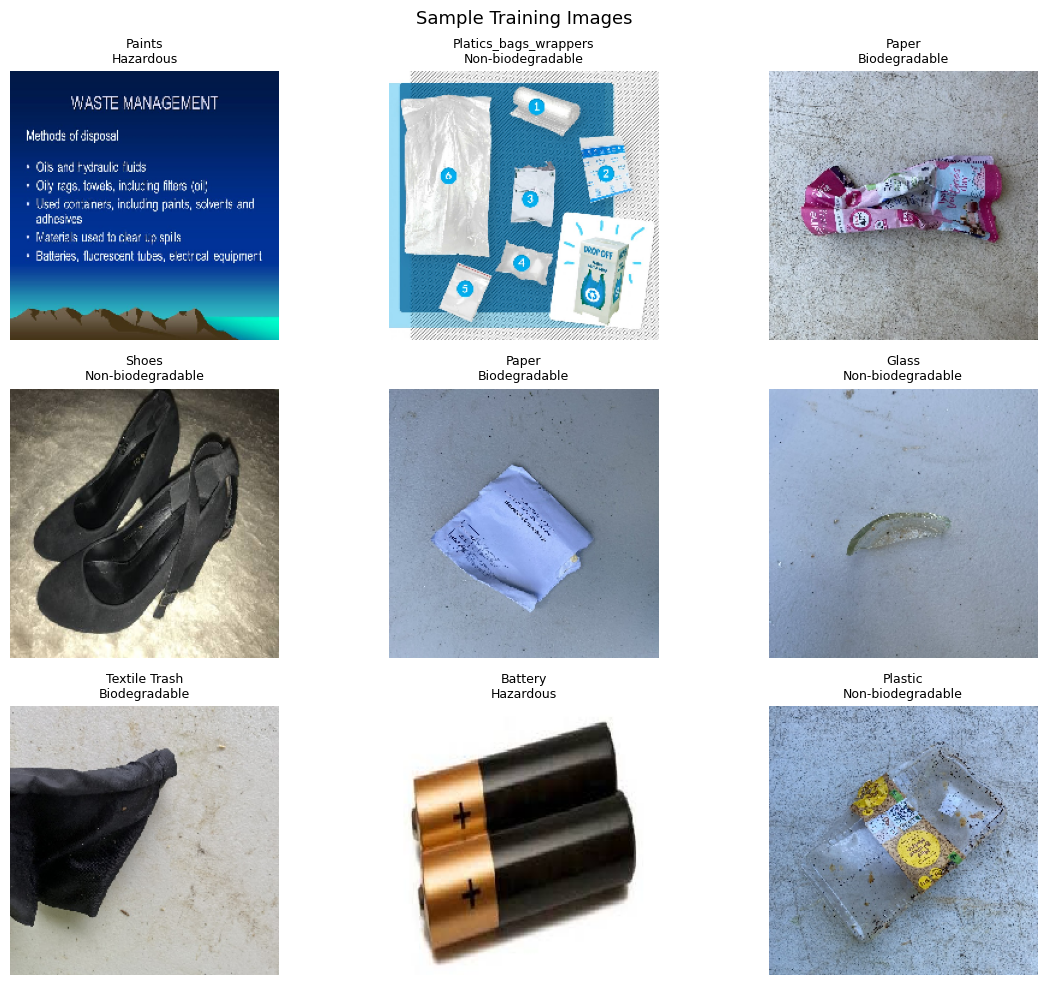

In [8]:
plt.figure(figsize=(12, 10))
sample_df = train_df.sample(9, random_state=SEED)

for i, (_, row) in enumerate(sample_df.iterrows()):
    image = tf.keras.utils.load_img(row["image_path"], target_size=(IMG_HEIGHT, IMG_WIDTH))
    image = tf.keras.utils.img_to_array(image)

    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(image.astype("uint8"))
    plt.title(f'{row["subcategory"]}\n{row["main_category"]}', fontsize=9)
    plt.axis("off")

plt.suptitle("Sample Training Images", fontsize=13)
plt.tight_layout()
plt.show()


## Step 9: Create TensorFlow Datasets

In [9]:
class_to_index = {name: idx for idx, name in enumerate(class_names)}

def load_image(image_path, label):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image = tf.image.resize(image, [IMG_HEIGHT, IMG_WIDTH])
    image = tf.cast(image, tf.float32)
    return image, label

def create_dataset(dataframe, shuffle=False):
    paths  = dataframe["image_path"].values
    labels = dataframe["subcategory"].map(class_to_index).values
    ds     = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds     = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(buffer_size=len(dataframe), seed=SEED)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = create_dataset(train_df, shuffle=True)
val_ds   = create_dataset(val_df,   shuffle=False)
test_ds  = create_dataset(test_df,  shuffle=False)

print("TensorFlow datasets created successfully.")
print(f"  Train batches : {len(train_ds)}")
print(f"  Val batches   : {len(val_ds)}")
print(f"  Test batches  : {len(test_ds)}")


TensorFlow datasets created successfully.
  Train batches : 125
  Val batches   : 27
  Test batches  : 27


## Step 10: Data Augmentation

In [10]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1)
], name="data_augmentation")

print("Data augmentation pipeline created!")


Data augmentation pipeline created!


## Step 11: Build DenseNet121 Model

In [11]:
# Load pretrained DenseNet121 (downloads weights on first run)
base_model = DenseNet121(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)
base_model.trainable = False   # Freeze base initially

# Build full model
inputs  = layers.Input(shape=(224, 224, 3))
x       = data_augmentation(inputs)
x       = preprocess_input(x)                     # Scale to DenseNet range
x       = base_model(x, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.Dense(256, activation="relu")(x)
x       = layers.BatchNormalization()(x)
x       = layers.Dropout(0.4)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = models.Model(inputs, outputs)

print("DenseNet121 model built!")
print(f"  Total layers      : {len(model.layers)}")
print(f"  Trainable layers  : {sum(l.trainable for l in model.layers)}")
model.summary()


DenseNet121 model built!
  Total layers      : 8
  Trainable layers  : 7


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add (Add)                       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 17)             │         4,369 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,305,297 (27.87 MB)

 Trainable params: 267,281 (1.02 MB)

 Non-trainable params: 7,038,016 (26.85 MB)

## Step 12: Compile & Train — Phase 1 (Frozen Base)
> ⚠️ NaN loss fix applied here — stable LR + clipnorm

In [12]:
# Compile with stable settings (fixes NaN loss issue)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4, clipnorm=1.0),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=["accuracy"]
)

# Callbacks
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True, verbose=1
)
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6, verbose=1
)
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    MODEL_SAVE_PATH, monitor="val_accuracy", save_best_only=True, verbose=1
)

initial_epochs = 10

print("Starting Phase 1 training (frozen base)...")
history_initial = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=initial_epochs,
    callbacks=[early_stopping, reduce_lr, checkpoint]
)
print("Phase 1 training complete!")


Starting Phase 1 training (frozen base)...
Epoch 1/10


c:\Users\Student\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2580 - loss: 2.7718
Epoch 1: val_accuracy improved from None to 0.50822, saving model to C:\Users\Student\Desktop\mini_project\initial_model.keras

Epoch 1: finished saving model to C:\Users\Student\Desktop\mini_project\initial_model.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 231s 2s/step - accuracy: 0.2580 - loss: 2.7718 - val_accuracy: 0.5082 - val_loss: 1.5864 - learning_rate: 1.0000e-04
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5153 - loss: 1.6312
Epoch 2: val_accuracy improved from 0.50822 to 0.62676, saving model to C:\Users\Student\Desktop\mini_project\initial_model.keras

Epoch 2: finished saving model to C:\Users\Student\Desktop\mini_project\initial_model.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 176s 1s/step - accuracy: 0.5153 - loss: 1.6312 - val_accuracy: 0.6268 - val_loss: 1.1401 - learning_rate: 1.0000e-04
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6069 - loss: 1.2657
Epoch 3: val_accuracy

## Step 13: Plot Phase 1 Training History

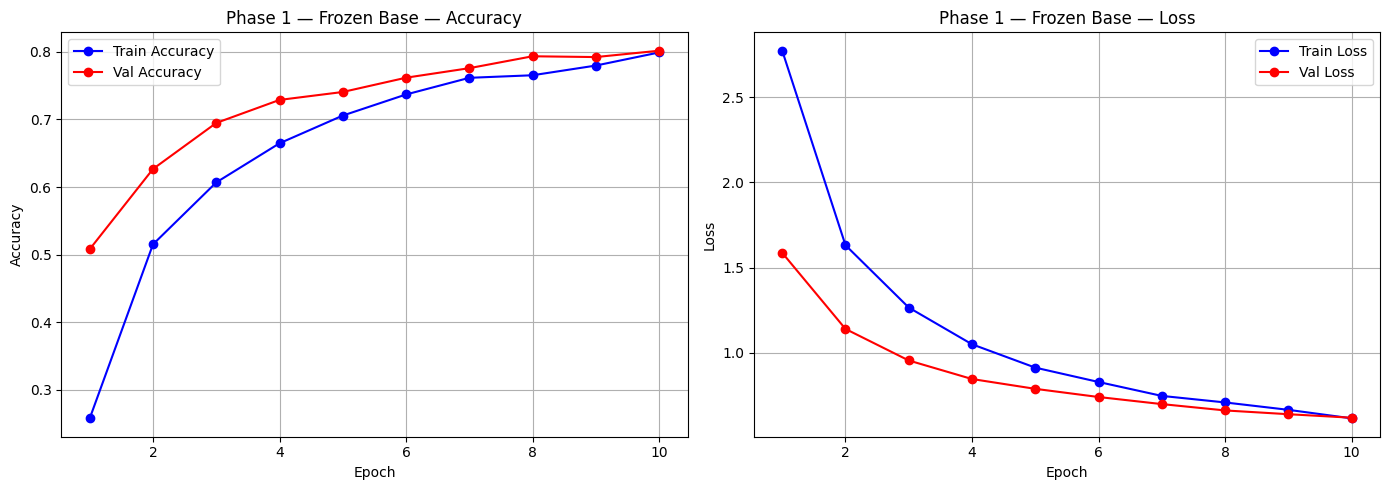

In [13]:
def plot_history(history, title="Training History"):
    acc      = history.history["accuracy"]
    val_acc  = history.history["val_accuracy"]
    loss     = history.history["loss"]
    val_loss = history.history["val_loss"]
    epochs_range = range(1, len(acc) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(epochs_range, acc,     "b-o", label="Train Accuracy")
    axes[0].plot(epochs_range, val_acc, "r-o", label="Val Accuracy")
    axes[0].set_title(f"{title} — Accuracy")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(epochs_range, loss,     "b-o", label="Train Loss")
    axes[1].plot(epochs_range, val_loss, "r-o", label="Val Loss")
    axes[1].set_title(f"{title} — Loss")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

plot_history(history_initial, title="Phase 1 — Frozen Base")


## Step 14: Fine-Tuning — Phase 2 (Unfreeze Top Layers)

In [15]:
# Unfreeze top layers of DenseNet121
base_model.trainable = True

fine_tune_at = 100   # Keep first 100 layers frozen
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

print(f"Total base model layers     : {len(base_model.layers)}")
print(f"Trainable layers after unfreeze: {sum(l.trainable for l in base_model.layers)}")

# Re-compile with much lower LR for fine-tuning
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5, clipnorm=1.0),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=["accuracy"]
)

fine_tune_epochs = 15
total_epochs     = initial_epochs + fine_tune_epochs

checkpoint_ft = tf.keras.callbacks.ModelCheckpoint(
    FINETUNED_PATH, monitor="val_accuracy", save_best_only=True, verbose=1
)

print("Starting Phase 2 fine-tuning...")
history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=total_epochs,
    initial_epoch=len(history_initial.history["accuracy"]),
    callbacks=[early_stopping, reduce_lr, checkpoint_ft]
)
print("Fine-tuning complete!")


Total base model layers     : 427
Trainable layers after unfreeze: 327
Starting Phase 2 fine-tuning...
Epoch 11/25


125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7324 - loss: 0.8310
Epoch 11: val_accuracy improved from None to 0.79930, saving model to C:\Users\Student\Desktop\mini_project\finetuned_model.keras

Epoch 11: finished saving model to C:\Users\Student\Desktop\mini_project\finetuned_model.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 486s 4s/step - accuracy: 0.7324 - loss: 0.8310 - val_accuracy: 0.7993 - val_loss: 0.6760 - learning_rate: 1.0000e-05
Epoch 12/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7782 - loss: 0.6878
Epoch 12: val_accuracy did not improve from 0.79930
125/125 ━━━━━━━━━━━━━━━━━━━━ 475s 4s/step - accuracy: 0.7782 - loss: 0.6878 - val_accuracy: 0.7934 - val_loss: 0.6859 - learning_rate: 1.0000e-05
Epoch 13/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7985 - loss: 0.6165
Epoch 13: val_accuracy did not improve from 0.79930
125/125 ━━━━━━━━━━━━━━━━━━━━ 451s 4s/step - accuracy: 0.7985 - loss: 0.6165 - val_accuracy: 0.7993 - val_loss: 0.6658 - learning_rat

## Step 15: Plot Fine-Tuning History

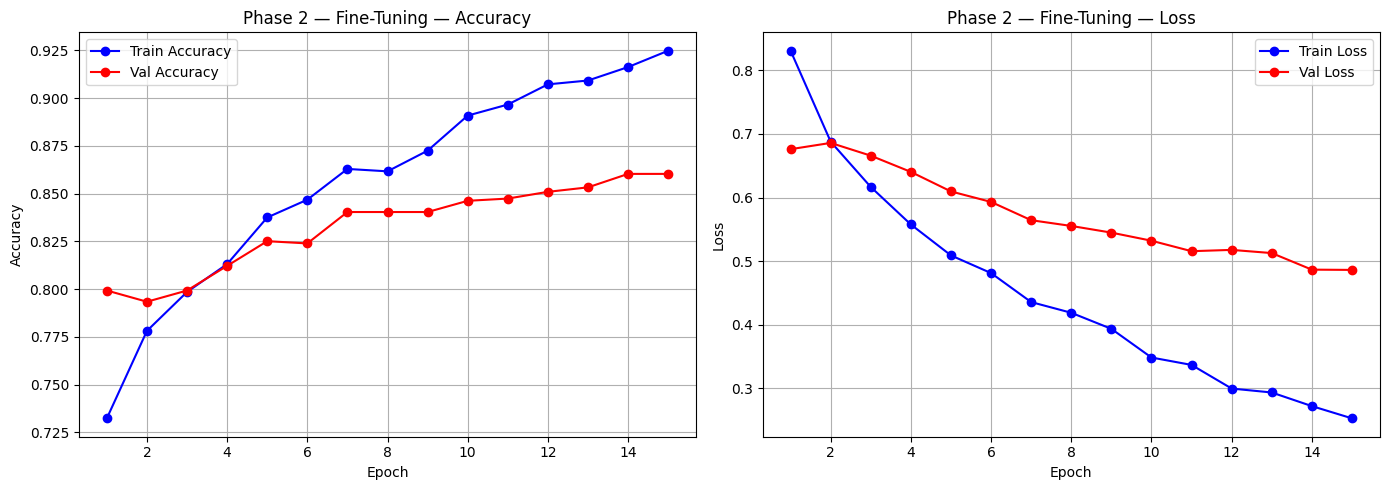

In [16]:
plot_history(history_fine, title="Phase 2 — Fine-Tuning")


## Step 16: Evaluate on Test Set

In [17]:
print("Evaluating on test set...")
test_loss, test_accuracy = model.evaluate(test_ds, verbose=1)

print(f"\n{'='*40}")
print(f"  Test Loss     : {test_loss:.4f}")
print(f"  Test Accuracy : {test_accuracy * 100:.2f}%")
print(f"{'='*40}")


Evaluating on test set...
27/27 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.8488 - loss: 0.4966

  Test Loss     : 0.4966
  Test Accuracy : 84.88%


## Step 17: Classification Report

In [18]:
all_true_labels = []
all_pred_labels = []

for images, labels in test_ds:
    preds        = model.predict(images, verbose=0)
    pred_classes = np.argmax(preds, axis=1)
    all_true_labels.extend(labels.numpy())
    all_pred_labels.extend(pred_classes)

all_true_labels = np.array(all_true_labels)
all_pred_labels = np.array(all_pred_labels)

print("Classification Report:")
print("=" * 60)
print(classification_report(
    all_true_labels,
    all_pred_labels,
    target_names=class_names,
    digits=4
))


Classification Report:
                       precision    recall  f1-score   support

              Battery     1.0000    0.9912    0.9956       114
                 Cans     0.8043    0.9250    0.8605        40
            Cardboard     0.7901    0.9275    0.8533        69
      Ceramic_product     0.9000    0.4737    0.6207        19
              Diapers     0.9286    0.6190    0.7429        21
                Glass     0.8871    0.8730    0.8800        63
                Metal     0.8162    0.9328    0.8706       119
               Paints     0.5714    0.5217    0.5455        23
                Paper     0.8800    0.8800    0.8800        75
           Pesticides     0.7500    0.7143    0.7317        21
              Plastic     0.9369    0.7536    0.8353       138
      Plastic_bottles     0.7857    0.6111    0.6875        18
Platics_bags_wrappers     0.6250    0.7500    0.6818        20
      Sanitary_napkin     0.3793    0.6875    0.4889        16
                Shoes     1.000

## Step 18: Confusion Matrix

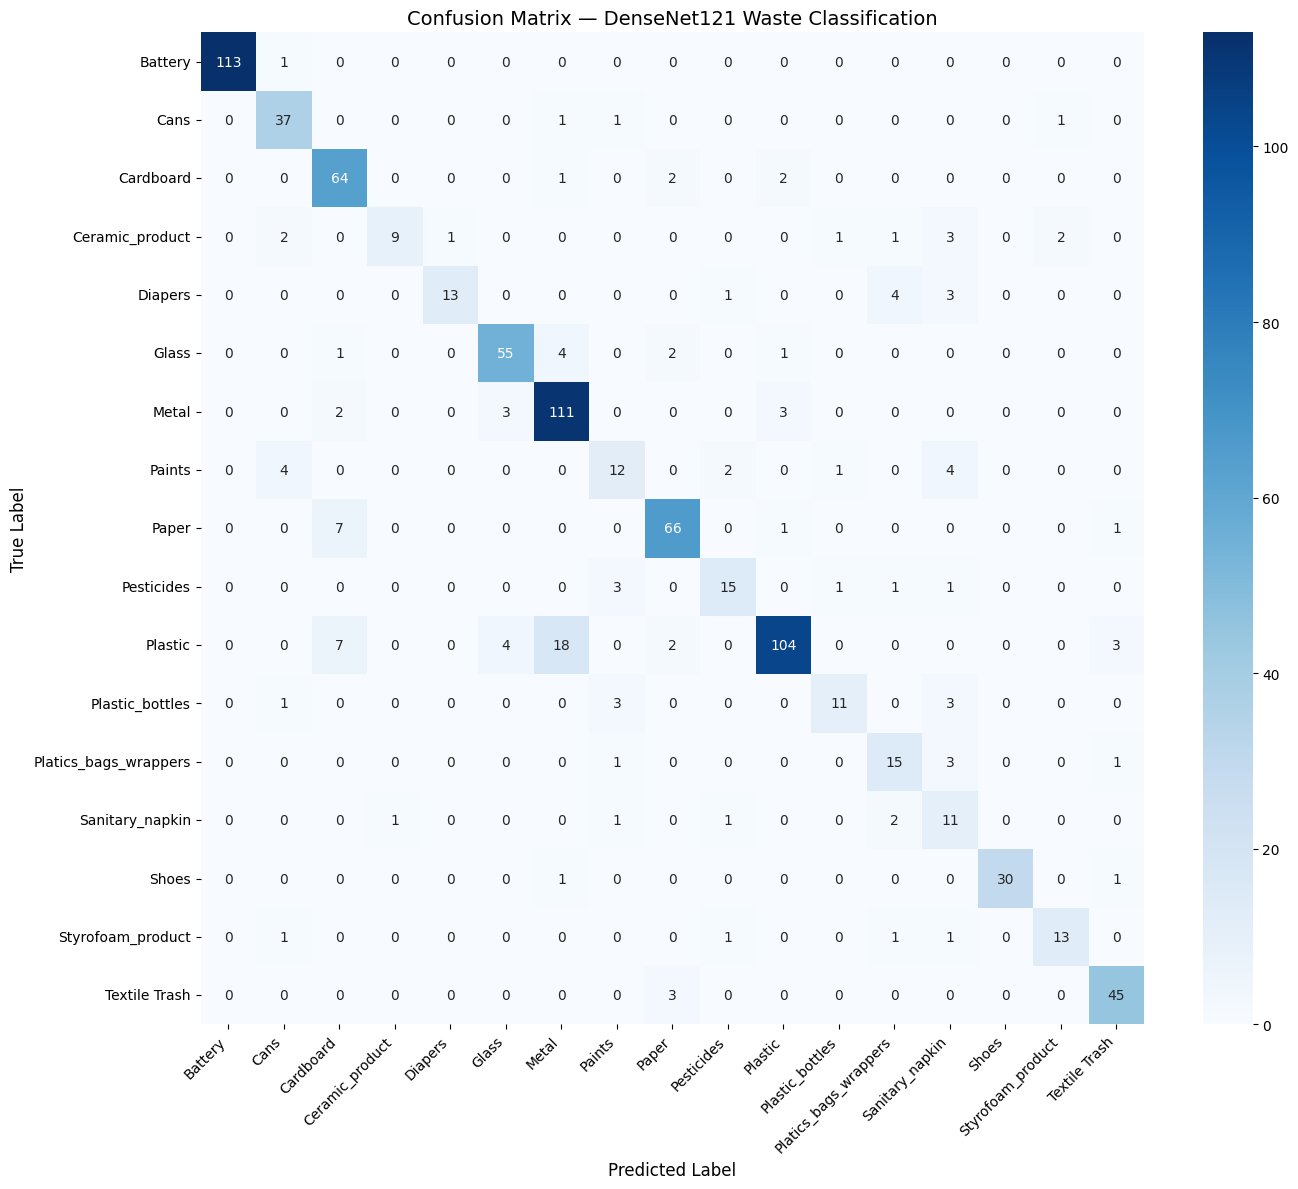

In [19]:
cm = confusion_matrix(all_true_labels, all_pred_labels)

plt.figure(figsize=(14, 12))
sns.heatmap(
    cm,
    annot=True, fmt="d", cmap="Blues",
    xticklabels=class_names, yticklabels=class_names
)
plt.title("Confusion Matrix — DenseNet121 Waste Classification", fontsize=14)
plt.ylabel("True Label",      fontsize=12)
plt.xlabel("Predicted Label", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


## Step 19: Visualize Sample Predictions

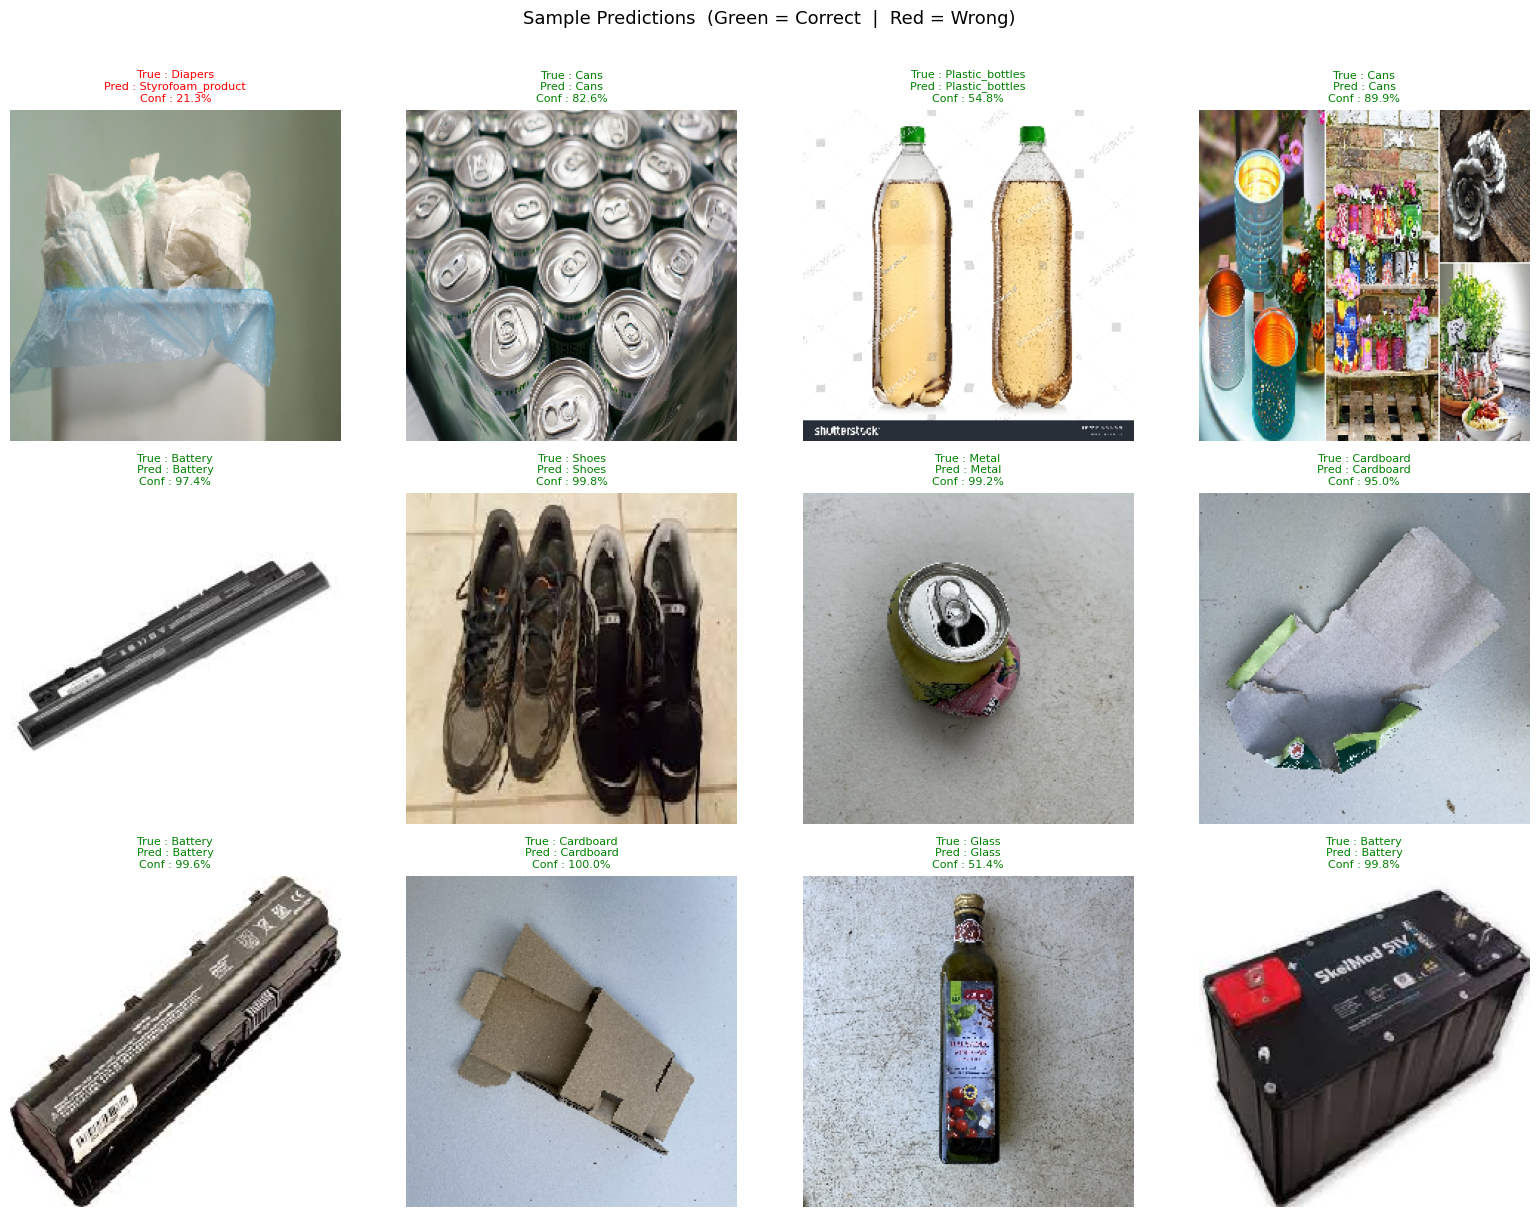

In [21]:
index_to_class = {v: k for k, v in class_to_index.items()}
sample_test    = test_df.sample(12, random_state=42).reset_index(drop=True)

plt.figure(figsize=(16, 12))

for i, (_, row) in enumerate(sample_test.iterrows()):
    img       = tf.keras.utils.load_img(row["image_path"], target_size=(IMG_HEIGHT, IMG_WIDTH))
    img_array = tf.keras.utils.img_to_array(img)
    img_batch = np.expand_dims(img_array, axis=0)

    preds      = model.predict(img_batch, verbose=0)
    pred_idx   = np.argmax(preds[0])
    confidence = preds[0][pred_idx] * 100

    pred_label = index_to_class[pred_idx]
    true_label = row["subcategory"]
    color      = "green" if pred_label == true_label else "red"

    plt.subplot(3, 4, i + 1)
    plt.imshow(img_array.astype("uint8"))
    plt.title(
        f"True : {true_label}\nPred : {pred_label}\nConf : {confidence:.1f}%",
        fontsize=8, color=color
    )
    plt.axis("off")

plt.suptitle("Sample Predictions  (Green = Correct  |  Red = Wrong)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


## Step 20: Predict on a Single New Image


  Image : battery_390.jpg
  Rank   Class                     Confidence
  -------------------------------------------
  1      Battery                       99.60%  ◄ TOP PREDICTION
  2      Styrofoam_product              0.09%
  3      Cardboard                      0.06%
  4      Pesticides                     0.05%
  5      Sanitary_napkin                0.04%



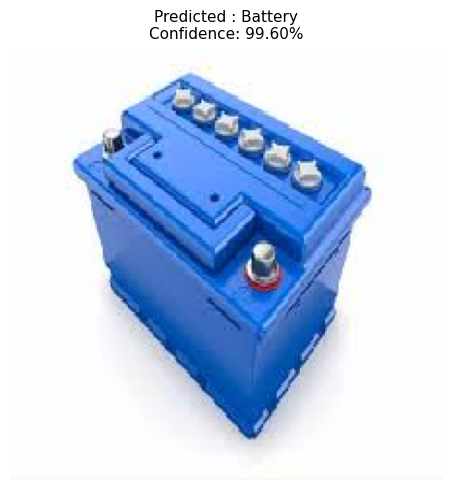

In [22]:
def predict_waste(image_path, top_k=3):
    """
    Predict waste category for any image.
    Args:
        image_path : path to the image file (string)
        top_k      : number of top predictions to display
    """
    img       = tf.keras.utils.load_img(image_path, target_size=(IMG_HEIGHT, IMG_WIDTH))
    img_array = tf.keras.utils.img_to_array(img)
    img_batch = np.expand_dims(img_array, axis=0)

    preds         = model.predict(img_batch, verbose=0)[0]
    top_k_indices = np.argsort(preds)[::-1][:top_k]

    print(f"\n{'='*48}")
    print(f"  Image : {os.path.basename(image_path)}")
    print(f"{'='*48}")
    print(f"  {'Rank':<6} {'Class':<25} {'Confidence':>10}")
    print(f"  {'-'*43}")
    for rank, idx in enumerate(top_k_indices, 1):
        marker = "  ◄ TOP PREDICTION" if rank == 1 else ""
        print(f"  {rank:<6} {index_to_class[idx]:<25} {preds[idx]*100:>9.2f}%{marker}")
    print(f"{'='*48}\n")

    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.title(
        f"Predicted : {index_to_class[top_k_indices[0]]}\n"
        f"Confidence: {preds[top_k_indices[0]]*100:.2f}%",
        fontsize=11
    )
    plt.axis("off")
    plt.tight_layout()
    plt.show()

    return {
        "predicted_class": index_to_class[top_k_indices[0]],
        "confidence"     : float(preds[top_k_indices[0]]),
        "top_k"          : [(index_to_class[i], float(preds[i])) for i in top_k_indices]
    }

# ── Test on a random test image ───────────────────────────────────────────────
sample_path = test_df.sample(1, random_state=7)["image_path"].values[0]
result      = predict_waste(sample_path, top_k=5)


## Step 21: Predict on Your Own Custom Image
> Change the path below to any image on your computer

In [23]:
# ── CHANGE THIS TO ANY IMAGE PATH ON YOUR COMPUTER ───────────────────────────
MY_IMAGE_PATH = r"C:/Users/YourName/Pictures/plastic_bottle.jpg"   # Example
# ─────────────────────────────────────────────────────────────────────────────

if os.path.exists(MY_IMAGE_PATH):
    result = predict_waste(MY_IMAGE_PATH, top_k=5)
else:
    print(f"Image not found: {MY_IMAGE_PATH}")
    print("Please update MY_IMAGE_PATH with a valid image path.")


Image not found: C:/Users/YourName/Pictures/plastic_bottle.jpg
Please update MY_IMAGE_PATH with a valid image path.


## Step 22: Save Final Model

In [24]:
model.save(FINAL_MODEL_PATH)
print(f"Final model saved → {FINAL_MODEL_PATH}")

with open(CLASS_NAMES_PATH, "wb") as f:
    pickle.dump(class_names, f)
print(f"Class names saved → {CLASS_NAMES_PATH}")


Final model saved → C:\Users\Student\Desktop\mini_project\final_model.keras
Class names saved → C:\Users\Student\Desktop\mini_project\class_names.pkl


## Step 23: Load Saved Model (Inference Only)
> Use this cell standalone to load and predict without retraining

In [25]:
# Load model and class names from disk
loaded_model = tf.keras.models.load_model(FINAL_MODEL_PATH)

with open(CLASS_NAMES_PATH, "rb") as f:
    loaded_class_names = pickle.load(f)

loaded_index_to_class = {i: c for i, c in enumerate(loaded_class_names)}

print("Model loaded successfully!")
print(f"Classes : {loaded_class_names}")

def predict_from_loaded_model(image_path, top_k=3):
    """Use the loaded (saved) model to predict — no need to retrain."""
    img       = tf.keras.utils.load_img(image_path, target_size=(224, 224))
    img_array = tf.keras.utils.img_to_array(img)
    img_batch = np.expand_dims(img_array, axis=0)

    preds         = loaded_model.predict(img_batch, verbose=0)[0]
    top_k_indices = np.argsort(preds)[::-1][:top_k]

    print(f"\nTop {top_k} Predictions for: {os.path.basename(image_path)}")
    for rank, idx in enumerate(top_k_indices, 1):
        print(f"  {rank}. {loaded_index_to_class[idx]:<25}  {preds[idx]*100:.2f}%")

    return loaded_index_to_class[top_k_indices[0]], float(preds[top_k_indices[0]])

# Test it
pred_class, confidence = predict_from_loaded_model(
    test_df.sample(1, random_state=10)["image_path"].values[0]
)
print(f"\nFinal Answer → {pred_class}  ({confidence*100:.2f}% confidence)")


Model loaded successfully!
Classes : ['Battery', 'Cans', 'Cardboard', 'Ceramic_product', 'Diapers', 'Glass', 'Metal', 'Paints', 'Paper', 'Pesticides', 'Plastic', 'Plastic_bottles', 'Platics_bags_wrappers', 'Sanitary_napkin', 'Shoes', 'Styrofoam_product', 'Textile Trash']

Top 3 Predictions for: Plastic_458.jpg
  1. Plastic                    99.80%
  2. Metal                      0.13%
  3. Glass                      0.04%

Final Answer → Plastic  (99.80% confidence)


## Summary

| Phase | Details |
|---|---|
| **Model** | DenseNet121 (ImageNet pretrained) |
| **Classes** | 17 waste subcategories |
| **Phase 1** | Frozen base, 10 epochs, lr=1e-4 |
| **Phase 2** | Unfreeze top layers, 10 epochs, lr=1e-5 |
| **Input Size** | 224 × 224 × 3 |
| **Augmentation** | Flip, Rotation, Zoom, Contrast |
| **Optimizer** | Adam + clipnorm=1.0 |
| **Loss** | SparseCategoricalCrossentropy |
| **Callbacks** | EarlyStopping, ReduceLROnPlateau, ModelCheckpoint |
| **NaN Fix** | clipnorm=1.0, LR=1e-4, ReduceLR factor=0.5 (not 0.2) |
